# EDA on Paris Property Price Dataset 

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
df = pd.read_csv(r'C:\Users\karan.chawla\Desktop\paris_housing_prices_dataset.csv')
df

,Property_ID,Arrondissement,Property_Type,Size_sqm,Rooms,Floor,Year_Built,Condition,Distance_to_Center_km,Price_EUR
0,P10000,4,Apartment,117,4,7,1870,Renovated,2.76,2270802.89
1,P10001,8,Studio,89,3,3,1953,Good,10.77,1637076.12
2,P10002,4,Apartment,164,5,5,1979,Needs Renovation,3.14,3220782.59
3,P10003,2,Apartment,35,1,5,1938,New,4.72,407781.74
4,P10004,7,Studio,73,2,2,1957,New,7.96,624879.12
...,...,...,...,...,...,...,...,...,...,...
1195,P11195,14,Studio,173,5,5,2010,Renovated,2.42,2328490.48
1196,P11196,16,Penthouse,192,4,1,1965,Good,6.56,2794554.47
1197,P11197,6,Loft,123,2,7,1961,New,13.18,2247682.75
1198,P11198,8,Studio,151,2,1,1926,Good,14.43,1236847.52


In [4]:
df.shape

(1200, 10)

In [5]:
df.describe()

,Arrondissement,Size_sqm,Rooms,Floor,Year_Built,Distance_to_Center_km,Price_EUR
count,1200.00000,1200.000000,1200.000000,1200.000000,1200.0000,1200.000000,1.200000e+03
mean,10.81750,108.125833,3.000000,4.390833,1935.6725,7.755375,1.521459e+06
std,5.65811,54.176125,1.414214,2.899728,49.8934,4.179961,8.737896e+05
min,1.00000,15.000000,1.000000,0.000000,1850.0000,0.510000,1.205258e+05
25%,6.00000,62.000000,2.000000,2.000000,1894.0000,4.137500,7.847546e+05
50%,11.00000,108.000000,3.000000,4.000000,1935.0000,7.705000,1.430473e+06
75%,16.00000,157.000000,4.000000,7.000000,1977.0000,11.347500,2.125367e+06
max,20.00000,199.000000,5.000000,9.000000,2023.0000,14.990000,3.950832e+06


In [6]:
df.info()
df.nunique()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Property_ID            1200 non-null   str    
 1   Arrondissement         1200 non-null   int64  
 2   Property_Type          1200 non-null   str    
 3   Size_sqm               1200 non-null   int64  
 4   Rooms                  1200 non-null   int64  
 5   Floor                  1200 non-null   int64  
 6   Year_Built             1200 non-null   int64  
 7   Condition              1200 non-null   str    
 8   Distance_to_Center_km  1200 non-null   float64
 9   Price_EUR              1200 non-null   float64
dtypes: float64(2), int64(5), str(3)
memory usage: 93.9 KB


Property_ID              1200
Arrondissement             20
Property_Type               4
Size_sqm                  185
Rooms                       5
Floor                      10
Year_Built                174
Condition                   4
Distance_to_Center_km     805
Price_EUR                1200
dtype: int64

## Univariate

Price of houses (EUR)

<Axes: xlabel='Price_EUR'>

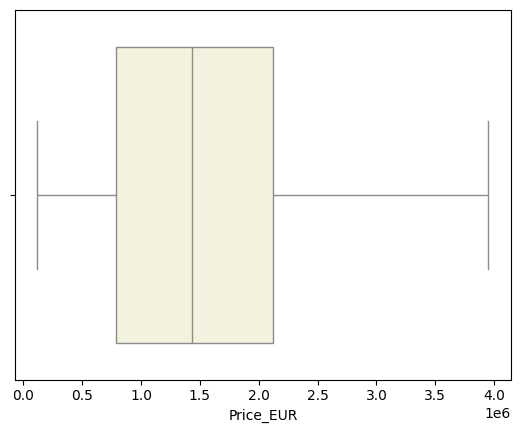

In [7]:
sns.boxplot(x=df['Price_EUR'], color='beige')

Size (sq m)

<Axes: xlabel='Size_sqm', ylabel='Count'>

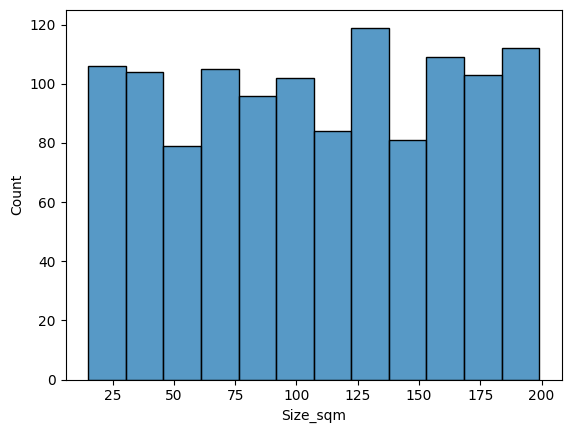

In [8]:
sns.histplot(x=df['Size_sqm'], element='bars')

Rooms

C:\Users\karan.chawla\AppData\Local\Temp\ipykernel_11472\1223701831.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Rooms'], palette='Set2', alpha=0.7)


<Axes: xlabel='Rooms', ylabel='count'>

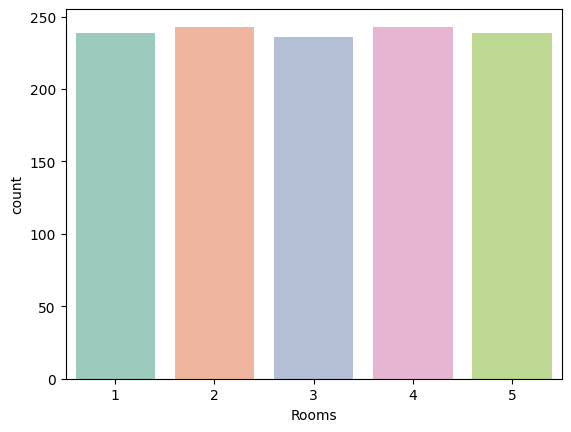

In [9]:
sns.countplot(x=df['Rooms'], palette='Set2', alpha=0.7)

Distance to Centre (km)

<Axes: xlabel='Distance_to_Center_km'>

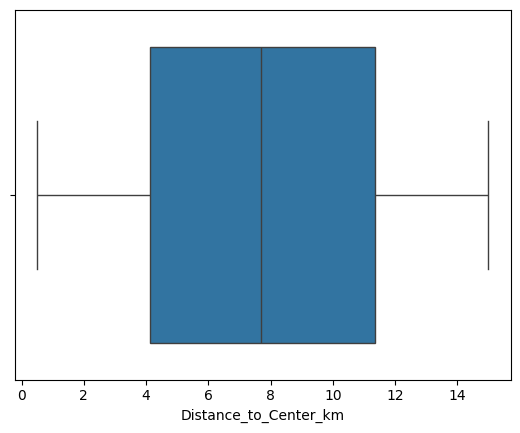

In [10]:
sns.boxplot(x=df['Distance_to_Center_km'])

Property Type

C:\Users\karan.chawla\AppData\Local\Temp\ipykernel_11472\586157520.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Property_Type'], palette='Set3')


<Axes: xlabel='Property_Type', ylabel='count'>

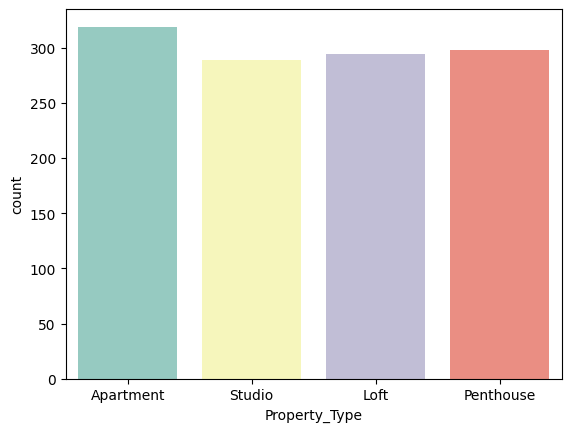

In [11]:
sns.countplot(x=df['Property_Type'], palette='Set3')

Condition of these houses

C:\Users\karan.chawla\AppData\Local\Temp\ipykernel_11472\1188465769.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Condition'], palette='Set2')


<Axes: xlabel='Condition', ylabel='count'>

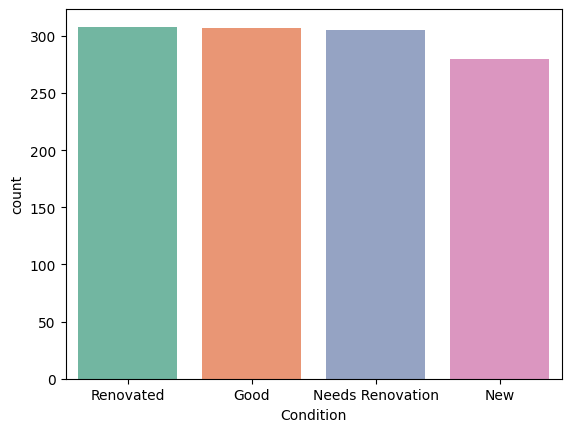

In [12]:
sns.countplot(x=df['Condition'], palette='Set2')

Districts

<Axes: xlabel='Arrondissement', ylabel='count'>

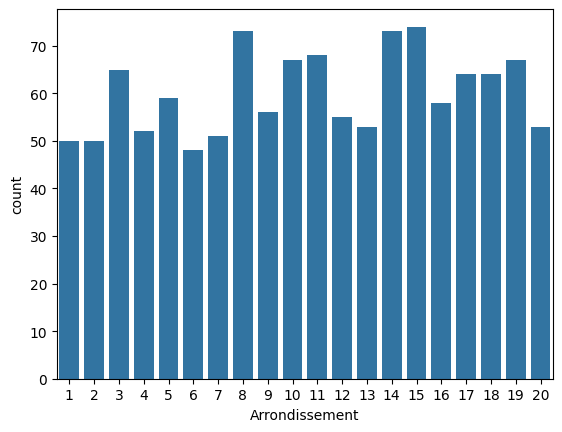

In [13]:
sns.countplot(x=df['Arrondissement'])

## Bivariate

### So what factors affect price?

Let's start with Size (sq m)

<Axes: xlabel='Size_sqm', ylabel='Price_EUR'>

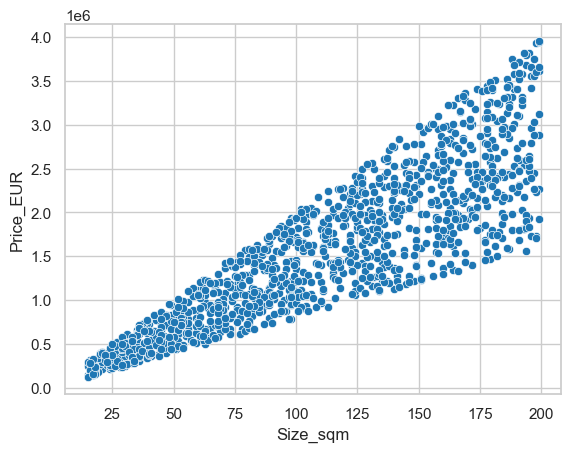

In [14]:
sns.set_style('whitegrid')
sns.set_context('notebook')
sns.scatterplot(data=df, x="Size_sqm", y="Price_EUR")

Observation: <br>
~ Yes, size matters but variance increases with size. Meaning:
1. Small properties have predictable pricing
2. Large properties do not have predictable pricing. Why?

In [15]:
df_large = df[df["Size_sqm"] > 100]

<Axes: xlabel='Condition', ylabel='Price_EUR'>

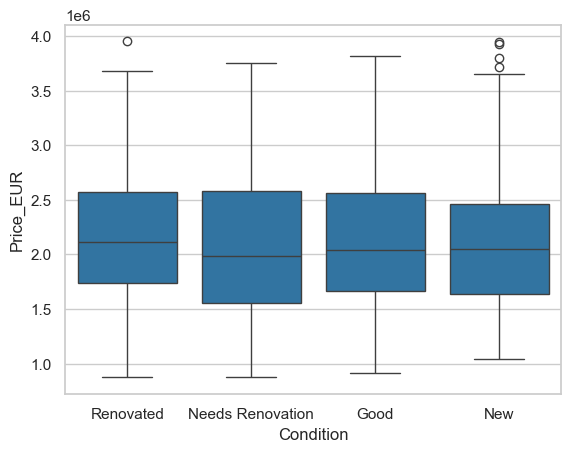

In [16]:
sns.boxplot(data=df_large, x="Condition", y="Price_EUR")

Observation:<br>
~ There is no evidence as such that the condition of the house impacts the price. There are a few outliers but that's it. Removing the outliers doesn't change my conclusion

Let's calculate the price per m<sup>2</sup> and then compare it to other factors

In [17]:
df['Price per sqm'] = df['Price_EUR'] / df['Size_sqm']

<Axes: xlabel='Distance_to_Center_km', ylabel='Price per sqm'>

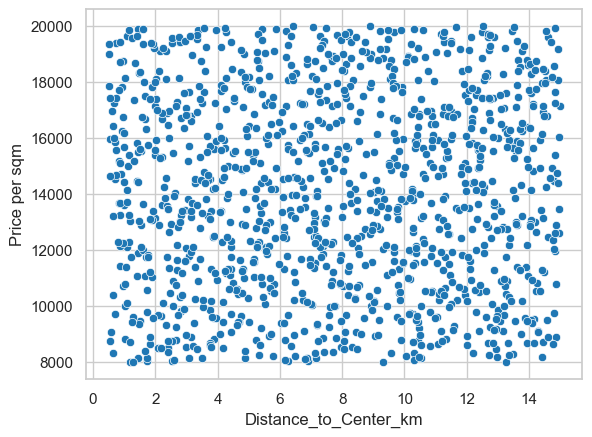

In [18]:
sns.scatterplot(data=df, x="Distance_to_Center_km", y="Price per sqm")

There is absolutely no relation between Distance to Centre and Price per m<sup>2</sup>. 

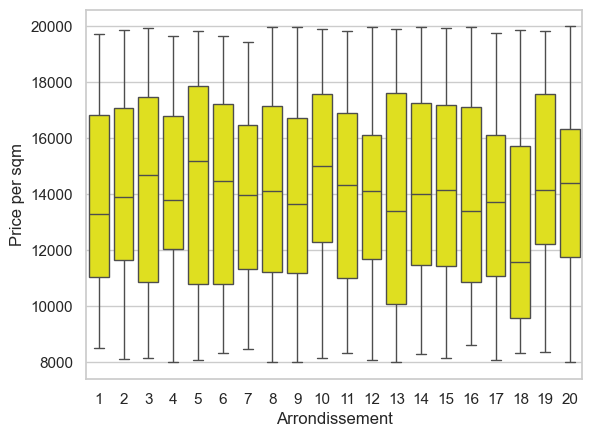

In [22]:
sns.boxplot( y=df['Price per sqm'],x=df['Arrondissement'],color='yellow')
sns.set_context('notebook')

Observation:<br>
~ The above does show that there is a relation between District and Price per m<sup>2</sup> <br>
~ Location does matter, but not in the way that it must be close to the centre <br>
~ Certain Districts are more valuable

<Axes: xlabel='Arrondissement', ylabel='Price_EUR'>

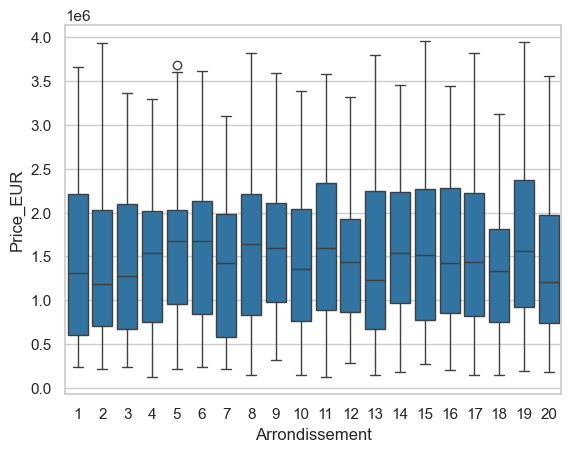

In [24]:
sns.boxplot(y=df['Price_EUR'], x=df['Arrondissement'])

Observation:<br>
~ While district shows some variation when being compared to total price, its effect is much clearer when analyzing price per square meter, indicating that location significantly influences property value rather than just total price.

In [34]:
corr = df.corr(numeric_only=True)

<Axes: >

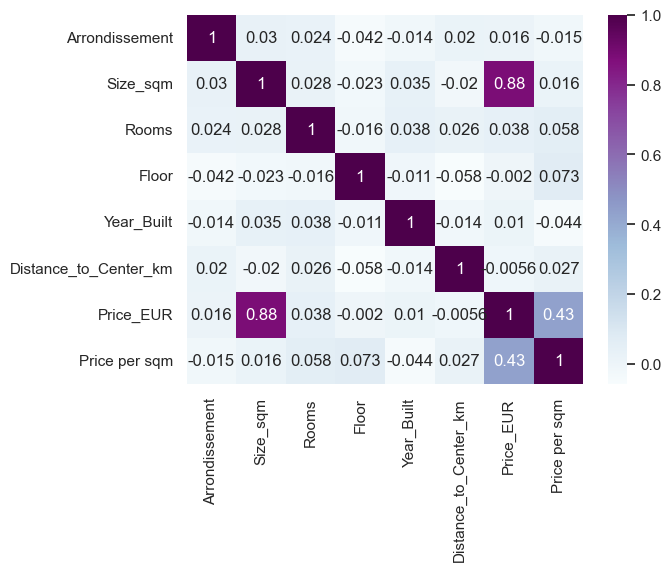

In [42]:
sns.heatmap(corr, annot=True, cmap="BuPu")
